In [3]:
# 📦 Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 🌀 Data Generators
IMG_SIZE = (128, 128)
BATCH = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    'im_train_aug_768', target_size=IMG_SIZE, batch_size=BATCH, class_mode='categorical')
test_data = test_datagen.flow_from_directory(
    'testset', target_size=IMG_SIZE, batch_size=BATCH, class_mode='categorical')

# 🧠 CNN Architecture
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(*IMG_SIZE,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()




Found 932 images belonging to 3 classes.
Found 386 images belonging to 3 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# 🛠️ Callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

# 🚀 Training
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=30,
    callbacks=callbacks)

# 📈 Plot Results
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')
plt.show()

ValueError: The filepath provided must end in `.keras` (Keras model format). Received: filepath=best_model.h5

Epoch 1/30


C:\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


30/30 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.3431 - loss: 1.1512 - val_accuracy: 0.5130 - val_loss: 1.0950
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 434ms/step - accuracy: 0.3697 - loss: 1.0994 - val_accuracy: 0.5130 - val_loss: 1.0495
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 431ms/step - accuracy: 0.3609 - loss: 1.0863 - val_accuracy: 0.5259 - val_loss: 1.0854
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 441ms/step - accuracy: 0.3969 - loss: 1.0957 - val_accuracy: 0.5130 - val_loss: 1.0101
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 436ms/step - accuracy: 0.4268 - loss: 1.0928 - val_accuracy: 0.4845 - val_loss: 1.0442
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 412ms/step - accuracy: 0.3649 - loss: 1.0925 - val_accuracy: 0.5130 - val_loss: 1.3517
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 423ms/step - accuracy: 0.4391 - loss: 1.0563 - val_accuracy: 0.4378 - val_loss: 0.8919
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 426ms/step - accuracy: 0.3688 - loss: 1.0927 - val_accuracy: 0.4637 -

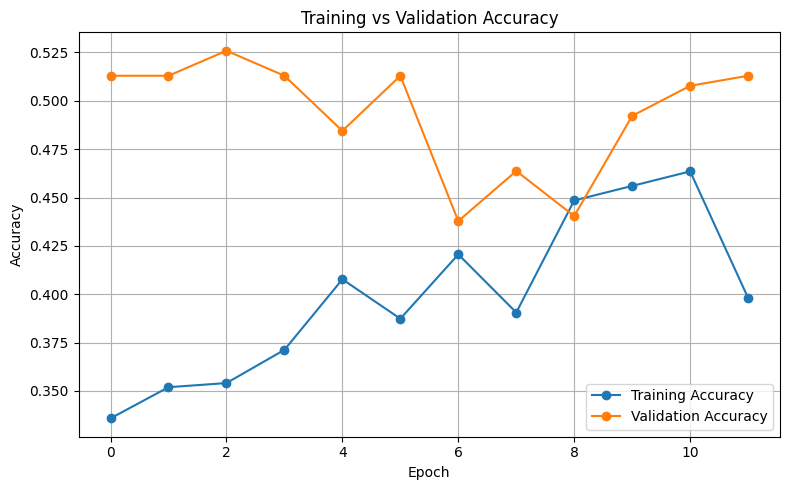

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# 🛠️ Callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True)  # Updated to .keras format
]

# 🚀 Model Training
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=30,
    callbacks=callbacks
)

# 📈 Plot Training and Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Rescaling, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# ✅ Define Model
model = Sequential([
    Input(shape=(128, 128, 3)),  # Fixes the warning
    Rescaling(1./255),

    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D(),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(),

    Dropout(0.3),
    Flatten(),

    Dense(128, activation='relu'),
    Dense(3, activation='softmax')  # Assuming 3 output classes
])

# ✅ Compile Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [1]:
# 📦 Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 🌀 Data Generators
IMG_SIZE = (128, 128)
BATCH = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    'im_train_aug_768', target_size=IMG_SIZE, batch_size=BATCH, class_mode='categorical')
test_data = test_datagen.flow_from_directory(
    'testset', target_size=IMG_SIZE, batch_size=BATCH, class_mode='categorical')

Found 932 images belonging to 3 classes.
Found 386 images belonging to 3 classes.


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Rescaling, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# ✅ Define Model
model = Sequential([
    Input(shape=(128, 128, 3)),  # Fixes the warning
    Rescaling(1./255),

    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D(),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(),

    Dropout(0.3),
    Flatten(),

    Dense(128, activation='relu'),
    Dense(3, activation='softmax')  # Assuming 3 output classes
])

# ✅ Compile Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [3]:
print("hello")

hello


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # if using a single dataset
)


In [5]:
Conv2D(128, (3, 3), activation='relu'),
MaxPooling2D(),


(<MaxPooling2D name=max_pooling2d_3, built=False>,)

In [6]:
from tensorflow.keras.layers import BatchNormalization

Conv2D(64, (3, 3), activation='relu'),
BatchNormalization(),
MaxPooling2D(),


(<MaxPooling2D name=max_pooling2d_4, built=False>,)

In [7]:
EarlyStopping(patience=10, restore_best_weights=True)


In [8]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)


In [9]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # Reduce LR by half
    patience=3,       # Wait 3 epochs before reducing
    verbose=1         # Print updates
)


In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True),
    reduce_lr  # 👈 Add it here
]


In [14]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30


ValueError: Input 0 of layer "functional_2" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(None, 128, 128, 3)

In [12]:
import numpy as np
print(np.unique(train_data.classes, return_counts=True))


(array([0, 1, 2]), array([316, 310, 306], dtype=int64))


In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
base.trainable = False  # Freeze feature extractor

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step


In [15]:
image_size = (224, 224)


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    'im_train_aug_768',
    target_size=image_size,
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    'testset',
    target_size=image_size,
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 746 images belonging to 3 classes.
Found 76 images belonging to 3 classes.


In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint('best_model.keras', save_best_only=True)
]


In [19]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30


ValueError: Creating variables on a non-first call to a function decorated with tf.function.

In [20]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf

# 1. Set image size and batch size
image_size = (224, 224)
batch_size = 32

# 2. Load data with augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    'im_train_aug_768',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    'testset',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# 3. Define the model
base = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
base.trainable = False  # Freeze base model

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base.input, outputs=output)

# 4. Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 5. Define callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint('best_model.keras', save_best_only=True)
]

# 6. ✅ Train the model (do this only after model.compile)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks
)


Found 746 images belonging to 3 classes.
Found 76 images belonging to 3 classes.
Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 739ms/step - accuracy: 0.5432 - loss: 1.1061 - val_accuracy: 0.8947 - val_loss: 0.2825 - learning_rate: 0.0010
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 628ms/step - accuracy: 0.8516 - loss: 0.3874 - val_accuracy: 0.8684 - val_loss: 0.2544 - learning_rate: 0.0010
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 621ms/step - accuracy: 0.8955 - loss: 0.2645 - val_accuracy: 0.8684 - val_loss: 0.2218 - learning_rate: 0.0010
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 654ms/step - accuracy: 0.8892 - loss: 0.2764 - val_accuracy: 0.9342 - val_loss: 0.2079 - learning_rate: 0.0010
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 664ms/step - accuracy: 0.8978 - loss: 0.2413 - val_accuracy: 0.8947 - val_loss: 0.2122 - learning_rate: 0.0010
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 646ms/step - accuracy: 0.9014 - loss: 0.2753 - val_accuracy: 0.8947 - val_loss: 0.2267 - learning_rate: 0.0010
E

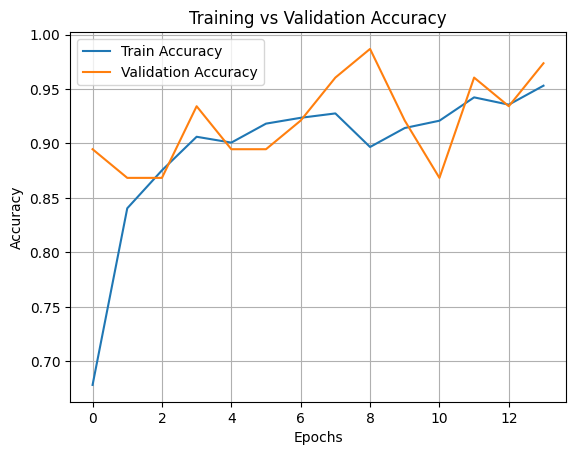

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [22]:
test_loss, test_acc = model.evaluate(test_data)
print(f"Test accuracy: {test_acc:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.5301 - loss: 1.1911 
Test accuracy: 0.5078


In [23]:
base.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Fine-tune
model.fit(train_data, validation_data=val_data, epochs=10, callbacks=callbacks)


Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.6987 - loss: 0.8393 - val_accuracy: 0.9868 - val_loss: 0.0715 - learning_rate: 1.0000e-05
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7465 - loss: 0.6180 - val_accuracy: 0.9474 - val_loss: 0.0875 - learning_rate: 1.0000e-05
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8254 - loss: 0.4597 - val_accuracy: 0.9342 - val_loss: 0.1097 - learning_rate: 1.0000e-05
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8764 - loss: 0.3603
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8759 - loss: 0.3608 - val_accuracy: 0.9211 - val_loss: 0.1703 - learning_rate: 1.0000e-05
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8650 - loss: 0.3665 - val_accuracy: 0.9605 - val_loss: 0.0936 - learning_rate: 5.0000e-06
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8841 - loss: 0.286

In [24]:
model.save('final_model.keras')
# Later: tf.keras.models.load_model('final_model.keras')


In [26]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img('testset/iii/iii_cut10-500-03-H-12mm-1000x16_4_3.png', target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [27]:
from tensorflow.keras.models import load_model

model = load_model('final_model.keras')


In [40]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = 'testset/iii/iii_cut10-500-03-H-9mm-1000x11_4_3.png'  # Replace with your image path
img = image.load_img(img_path, target_size=(224, 224))  # MobileNetV2 input size
img_array = image.img_to_array(img) / 255.0  # Normalize
img_array = np.expand_dims(img_array, axis=0)  # Shape: (1, 224, 224, 3)


In [41]:
pred = model.predict(img_array)  # Shape: (1, num_classes)
predicted_class = np.argmax(pred)  # Integer index of predicted class
confidence = np.max(pred)  # Probability/confidence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [42]:
class_indices = train_data.class_indices  # {'cat': 0, 'dog': 1, ...}
class_labels = list(class_indices.keys())  # ['cat', 'dog', ...]

print(f"Predicted class: {class_labels[predicted_class]} with confidence: {confidence:.2f}")


Predicted class: iii with confidence: 0.98


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 815ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


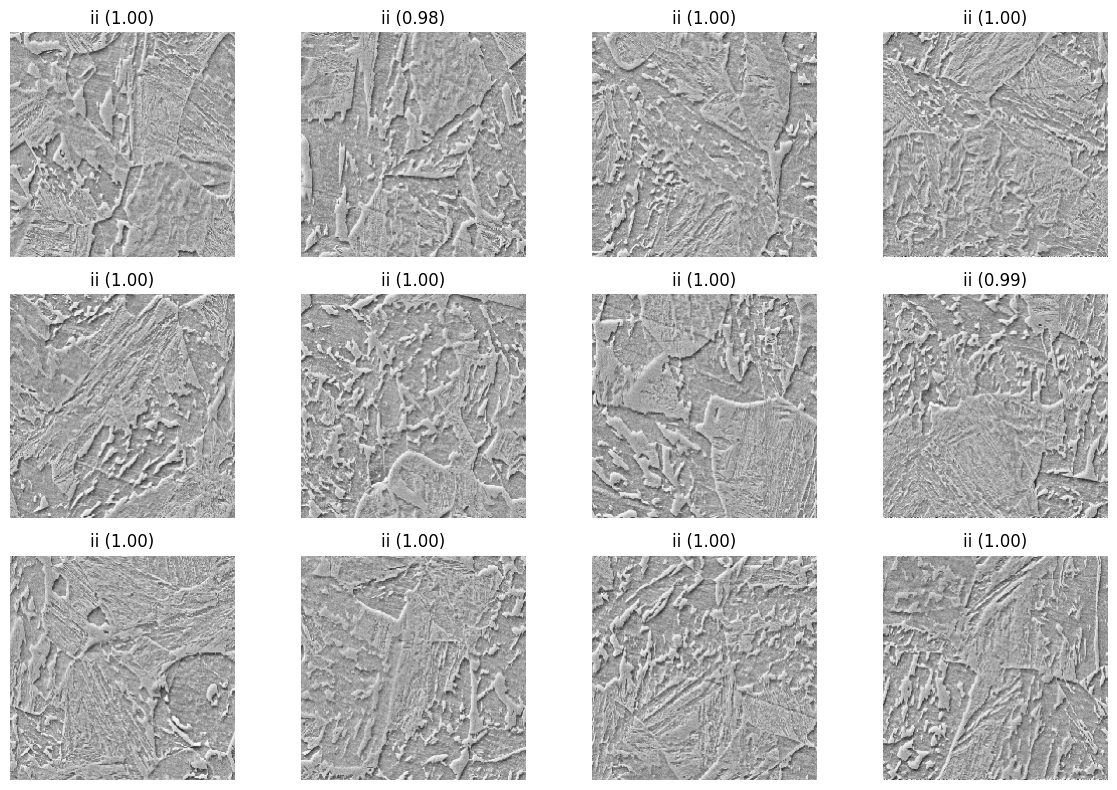

In [55]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load trained model
model = load_model('final_model.keras')

# Image folder path
image_folder = 'testset/ii'
image_size = (224, 224)

# Get class labels from training data
class_indices = train_data.class_indices  # Requires existing train_data
class_labels = list(class_indices.keys())

# Helper: load and preprocess a single image
def load_and_prepare(img_path):
    img = image.load_img(img_path, target_size=image_size)
    img_array = image.img_to_array(img) / 255.0
    return np.expand_dims(img_array, axis=0)

# Predict and plot
plt.figure(figsize=(12, 8))
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.jpg', '.png'))]

for i, fname in enumerate(image_files[:12]):  # Show up to 12 images
    img_path = os.path.join(image_folder, fname)
    img_prepped = load_and_prepare(img_path)
    pred = model.predict(img_prepped)
    pred_class = np.argmax(pred)
    confidence = np.max(pred)

    # Plot
    plt.subplot(3, 4, i + 1)
    img = image.load_img(img_path, target_size=image_size)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{class_labels[pred_class]} ({confidence:.2f})")

plt.tight_layout()
plt.show()


In [44]:
class_labels = [
    "Class I: lower bainite with small and elongated M-A islands",
    "Class II: inhomogeneous mix of large and small M-A islands",
    "Class III: largest M-A islands visible"
]


Text(0.5, 1.0, 'Class I: lower bainite with small and elongated M-A islands\n(0.94)')

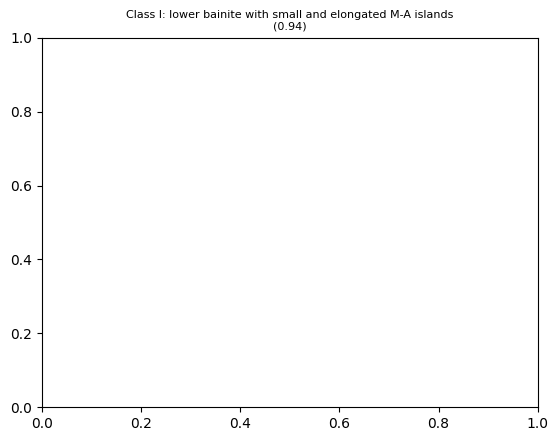

In [45]:
plt.title(f"{class_labels[pred_class]}\n({confidence:.2f})", fontsize=8)


In [46]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = 'testset/iii/iii_cut10-500-03-H-9mm-1000x11_4_3.png'  # Replace with your image path
img = image.load_img(img_path, target_size=(224, 224))  # MobileNetV2 input size
img_array = image.img_to_array(img) / 255.0  # Normalize
img_array = np.expand_dims(img_array, axis=0)  # Shape: (1, 224, 224, 3)

pred = model.predict(img_array)  # Shape: (1, num_classes)
predicted_class = np.argmax(pred)  # Integer index of predicted class
confidence = np.max(pred)  # Probability/confidence


In [47]:
pred = model.predict(img_array)  # Shape: (1, num_classes)
predicted_class = np.argmax(pred)  # Integer index of predicted class
confidence = np.max(pred)  # Probability/confidence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [51]:
# Custom descriptive class labels
class_labels = [
    "Class I: lower bainite with small and elongated M-A islands",
    "Class II: inhomogeneous mix of large and small M-A islands",
    "Class III: largest M-A islands visible"
]

# Print prediction result with custom label
print(f"Predicted class: {class_labels[predicted_class]} --> with confidence: {confidence:.2f}")


Predicted class: Class III: largest M-A islands visible --> with confidence: 0.98


In [56]:
model.save('final_model.h5')
